# ZOS — Feature Engineering & Importance

Builds a customer-level feature matrix from the cleaned transaction data, then trains a LightGBM model to rank features by their predictive power.

| Section | Description |
|---------|-------------|
| **1. Feature Engineering** | 10 feature groups aggregated per customer — RFM, channels, temporal patterns, balance, geography, merchants, trends |
| **2. Feature Importance** | LightGBM regression + SHAP analysis to identify the most predictive features |

> **Input:** `output/cleaned.csv` (produced by `analysis.ipynb`)  
> **Outputs:** `output/customer_features.csv`, plots `11–13`, and `feature_importance_table.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

# --- Paths ---
CLEANED  = "output/cleaned.csv"
FEATURES = "output/customer_features.csv"
OUT      = "output/"

print("Setup complete.")

Setup complete.


/Users/tashi/Desktop/misc/zos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Feature Engineering

All features are aggregated at the **customer level**. Only `status == 'success'` transactions are used for behavioural features (except status-rate features, which use the full dataset).

| # | Group | Description |
|---|-------|-------------|
| 1 | RFM | Recency, frequency, and monetary statistics |
| 2 | Transaction type | Counts and ratios of debit vs credit |
| 3 | Channel usage | Per-channel counts, ratios, primary channel, channel diversity |
| 4 | Temporal | Active days/months, peak hour, weekend ratio, day-of-week entropy |
| 5 | Status | Failure/pending/reversal counts and rates |
| 6 | Balance | Average, max, min, std of balance before transaction |
| 7 | Geography | Primary state, number of unique states and LGAs |
| 8 | Merchant | Unique merchant and MCC counts |
| 9 | Monthly trends | 3-month trend in count/amount, monthly volatility (CV) |
| 10 | Outliers | Count and ratio of flagged large-amount transactions |

In [2]:
df = pd.read_csv(CLEANED, parse_dates=["timestamp"])
print(f"Loaded: {df.shape}")

df_success = df[df["status"] == "success"].copy()
print(f"Successful transactions: {len(df_success):,}")

Loaded: (5000000, 24)
Successful transactions: 4,599,963


### 1. RFM Features

**Recency** — days since last transaction. **Frequency** — total successful transactions. **Monetary** — summary stats of transaction amount (total, mean, median, std, max, min).

In [3]:
ref_date = df["timestamp"].max()

rfm = df_success.groupby("customer_id").agg(
    recency_days    =("timestamp", lambda x: (ref_date - x.max()).days),
    frequency       =("transaction_id", "count"),
    monetary_total  =("amount", "sum"),
    monetary_mean   =("amount", "mean"),
    monetary_median =("amount", "median"),
    monetary_std    =("amount", "std"),
    monetary_max    =("amount", "max"),
    monetary_min    =("amount", "min"),
).reset_index()
rfm["monetary_std"] = rfm["monetary_std"].fillna(0)

print(f"RFM shape: {rfm.shape}")
rfm.head(3)

RFM shape: (100000, 9)


,customer_id,recency_days,frequency,monetary_total,monetary_mean,monetary_median,monetary_std,monetary_max,monetary_min
0,CUS-00000001,0,101135,6.834614e+09,67579.121966,13400.0,238748.959681,5000000.0,100.0
1,CUS-00000002,0,57973,3.759885e+09,64855.798389,13300.0,230618.558719,5000000.0,100.0
2,CUS-00000003,0,41816,2.748398e+09,65726.002009,13200.0,237212.806639,5000000.0,100.0


### 2. Transaction Type Features

Per-customer counts and ratios of debit vs credit transactions.

In [4]:
type_counts = df_success.groupby(["customer_id", "transaction_type"]).size().unstack(fill_value=0)
type_counts.columns = [f"txn_type_{c}_count" for c in type_counts.columns]
type_total  = type_counts.sum(axis=1)
type_ratios = type_counts.div(type_total, axis=0)
type_ratios.columns = [c.replace("_count", "_ratio") for c in type_ratios.columns]
type_feats = pd.concat([type_counts, type_ratios], axis=1).reset_index()

print(f"Type features shape: {type_feats.shape}")
type_feats.head(3)

Type features shape: (100000, 5)


,customer_id,txn_type_credit_count,txn_type_debit_count,txn_type_credit_ratio,txn_type_debit_ratio
0,CUS-00000001,35372,65763,0.349750,0.650250
1,CUS-00000002,20264,37709,0.349542,0.650458
2,CUS-00000003,14675,27141,0.350942,0.649058


### 3. Channel Usage Features

Per-channel counts and ratios, primary channel (most-used), and number of distinct channels used.

In [5]:
ch_counts  = df_success.groupby(["customer_id", "channel"]).size().unstack(fill_value=0)
ch_counts.columns = [f"channel_{c}_count" for c in ch_counts.columns]
ch_total   = ch_counts.sum(axis=1)
ch_ratios  = ch_counts.div(ch_total, axis=0)
ch_ratios.columns = [c.replace("_count", "_ratio") for c in ch_ratios.columns]
ch_primary = ch_counts.idxmax(axis=1).str.replace("channel_", "").str.replace("_count", "")

ch_feats = pd.concat([ch_counts, ch_ratios], axis=1).reset_index()
ch_feats["primary_channel"] = ch_primary.values
ch_feats["n_channels_used"] = (ch_counts > 0).sum(axis=1).values

print(f"Channel features shape: {ch_feats.shape}")
ch_feats.head(3)

Channel features shape: (100000, 17)


,customer_id,channel_agent_count,channel_atm_count,channel_branch_count,channel_mobile_count,channel_pos_count,channel_ussd_count,channel_web_count,channel_agent_ratio,channel_atm_ratio,channel_branch_ratio,channel_mobile_ratio,channel_pos_ratio,channel_ussd_ratio,channel_web_ratio,primary_channel,n_channels_used
0,CUS-00000001,538,20233,3090,35382,30550,1488,9854,0.005320,0.200059,0.030553,0.349849,0.302071,0.014713,0.097434,mobile,7
1,CUS-00000002,284,11524,1773,20424,17264,900,5804,0.004899,0.198782,0.030583,0.352302,0.297794,0.015524,0.100116,mobile,7
2,CUS-00000003,225,8268,1259,14755,12530,623,4156,0.005381,0.197723,0.030108,0.352855,0.299646,0.014899,0.099388,mobile,7


### 4. Temporal Behaviour Features

Covers tenure, active days/months, peak hour, weekend ratio, and day-of-week entropy (higher entropy = activity spread evenly across all days).

In [6]:
temp = df_success.groupby("customer_id").agg(
    first_txn_date   =("timestamp", "min"),
    last_txn_date    =("timestamp", "max"),
    weekend_txn_count=("is_weekend", "sum"),
    total_txn_count  =("transaction_id", "count"),
    mean_hour        =("hour", "mean"),
    std_hour         =("hour", "std"),
    n_active_days    =("date", "nunique"),
    n_active_months  =("month", lambda x: x.nunique()),
).reset_index()

temp["tenure_days"]       = (temp["last_txn_date"] - temp["first_txn_date"]).dt.days
temp["weekend_ratio"]     = temp["weekend_txn_count"] / temp["total_txn_count"]
temp["txn_per_active_day"]= temp["total_txn_count"] / temp["n_active_days"].clip(lower=1)
temp["std_hour"]          = temp["std_hour"].fillna(0)
temp = temp.drop(columns=["first_txn_date", "last_txn_date", "weekend_txn_count", "total_txn_count"])

# Peak hour (mode)
peak_hour = (
    df_success.groupby("customer_id")["hour"]
    .agg(lambda x: x.mode().iloc[0])
    .rename("peak_hour")
)
temp = temp.merge(peak_hour, on="customer_id")

# Day-of-week entropy
dow_counts  = df_success.groupby(["customer_id", "day_of_week"]).size().unstack(fill_value=0)
dow_probs   = dow_counts.div(dow_counts.sum(axis=1), axis=0)
dow_entropy = -(dow_probs * np.log2(dow_probs.clip(lower=1e-10))).sum(axis=1)
temp["dow_entropy"] = dow_entropy.values

print(f"Temporal features shape: {temp.shape}")
temp.head(3)

Temporal features shape: (100000, 10)


,customer_id,mean_hour,std_hour,n_active_days,n_active_months,tenure_days,weekend_ratio,txn_per_active_day,peak_hour,dow_entropy
0,CUS-00000001,15.219459,4.694297,730,12,729,0.286399,138.541096,20,2.807299
1,CUS-00000002,15.201335,4.731368,730,12,729,0.291049,79.415068,19,2.807141
2,CUS-00000003,15.257605,4.697908,730,12,729,0.284676,57.282192,18,2.807309


### 5. Status-Based Features

Counts and rates for each transaction status (success, failed, pending, reversed) using **all** transactions (not just successful ones).

In [7]:
status_counts   = df.groupby(["customer_id", "status"]).size().unstack(fill_value=0)
total_per_cust  = status_counts.sum(axis=1)
status_feats    = pd.DataFrame({"customer_id": status_counts.index})
status_feats["total_txn_all_status"] = total_per_cust.values
for col in status_counts.columns:
    status_feats[f"status_{col}_count"] = status_counts[col].values
    status_feats[f"status_{col}_rate"]  = (status_counts[col] / total_per_cust).values

print(f"Status features shape: {status_feats.shape}")
status_feats.head(3)

Status features shape: (100000, 10)


,customer_id,total_txn_all_status,status_failed_count,status_failed_rate,status_pending_count,status_pending_rate,status_reversed_count,status_reversed_rate,status_success_count,status_success_rate
0,CUS-00000001,109888,7674,0.069835,873,0.007944,206,0.001875,101135,0.920346
1,CUS-00000002,62855,4267,0.067886,498,0.007923,117,0.001861,57973,0.922329
2,CUS-00000003,45458,3207,0.070549,349,0.007677,86,0.001892,41816,0.919882


### 6. Balance Features

Summary statistics of `balance_before_ngn` and a count of balance-inconsistent transactions per customer.

In [8]:
bal = df_success.groupby("customer_id").agg(
    avg_balance_before          =("balance_before_ngn", "mean"),
    max_balance_before          =("balance_before_ngn", "max"),
    min_balance_before          =("balance_before_ngn", "min"),
    std_balance_before          =("balance_before_ngn", "std"),
    balance_inconsistent_count  =("balance_consistent", lambda x: (~x).sum()),
).reset_index()
bal["std_balance_before"] = bal["std_balance_before"].fillna(0)

print(f"Balance features shape: {bal.shape}")
bal.head(3)

Balance features shape: (100000, 6)


,customer_id,avg_balance_before,max_balance_before,min_balance_before,std_balance_before,balance_inconsistent_count
0,CUS-00000001,294969.218201,4.410054e+05,147004.235646,84879.864057,3171
1,CUS-00000002,96479.739593,1.445883e+05,48197.555072,27905.772515,5489
2,CUS-00000003,944443.480327,1.419795e+06,473274.450752,273252.825075,264


### 7. Geographic Features

Primary state (mode), number of unique states, and number of unique LGAs visited.

In [9]:
geo = df_success.groupby("customer_id").agg(
    primary_state   =("location_state", lambda x: x.mode().iloc[0]),
    n_unique_states =("location_state", "nunique"),
    n_unique_lgas   =("location_lga",   "nunique"),
).reset_index()

print(f"Geographic features shape: {geo.shape}")
geo.head(3)

Geographic features shape: (100000, 4)


,customer_id,primary_state,n_unique_states,n_unique_lgas
0,CUS-00000001,rivers,1,1
1,CUS-00000002,jigawa,1,1
2,CUS-00000003,imo,1,1


### 8. Merchant Features

Number of unique merchants and unique merchant category codes (MCC) used per customer. Rows where `merchant_name == 'unknown'` are excluded (P2P/internal transfers).

In [10]:
df_merch = df_success[df_success["merchant_name"] != "unknown"]
merch = df_merch.groupby("customer_id").agg(
    n_unique_merchants=("merchant_name",          "nunique"),
    n_unique_mcc      =("merchant_category_code", "nunique"),
).reset_index()

print(f"Merchant features shape: {merch.shape}")
merch.head(3)

Merchant features shape: (99595, 3)


,customer_id,n_unique_merchants,n_unique_mcc
0,CUS-00000001,45,14
1,CUS-00000002,45,14
2,CUS-00000003,45,14


### 9. Monthly Trend Features

Compares the **last 3 months** vs the **prior 3 months** of activity to measure growth/decline in transaction count and amount. Also computes monthly coefficient of variation (CV) as a measure of behavioural volatility.

In [11]:
df_success["ym"] = df_success["timestamp"].dt.to_period("M")
monthly_cust = df_success.groupby(["customer_id", "ym"]).agg(
    monthly_count =("transaction_id", "count"),
    monthly_amount=("amount",         "sum"),
).reset_index()

all_periods_sorted = sorted(monthly_cust["ym"].unique())
last_3  = all_periods_sorted[-3:]
prior_3 = all_periods_sorted[-6:-3]

recent = (
    monthly_cust[monthly_cust["ym"].isin(last_3)]
    .groupby("customer_id")
    .agg(recent_3m_count=("monthly_count", "sum"), recent_3m_amount=("monthly_amount", "sum"))
    .reset_index()
)
prior = (
    monthly_cust[monthly_cust["ym"].isin(prior_3)]
    .groupby("customer_id")
    .agg(prior_3m_count=("monthly_count", "sum"), prior_3m_amount=("monthly_amount", "sum"))
    .reset_index()
)

trend = recent.merge(prior, on="customer_id", how="outer").fillna(0)
trend["count_trend"]  = (trend["recent_3m_count"]  - trend["prior_3m_count"])  / trend["prior_3m_count"].clip(lower=1)
trend["amount_trend"] = (trend["recent_3m_amount"] - trend["prior_3m_amount"]) / trend["prior_3m_amount"].clip(lower=1)

# Monthly volatility (coefficient of variation)
monthly_vol = monthly_cust.groupby("customer_id").agg(
    monthly_count_std   =("monthly_count",  "std"),
    monthly_amount_std  =("monthly_amount", "std"),
    monthly_count_mean  =("monthly_count",  "mean"),
    monthly_amount_mean =("monthly_amount", "mean"),
).reset_index()
monthly_vol["monthly_count_cv"]  = monthly_vol["monthly_count_std"]  / monthly_vol["monthly_count_mean"].clip(lower=1)
monthly_vol["monthly_amount_cv"] = monthly_vol["monthly_amount_std"] / monthly_vol["monthly_amount_mean"].clip(lower=1)
monthly_vol = monthly_vol.fillna(0)

print(f"Trend features shape:   {trend.shape}")
print(f"Volatility features shape: {monthly_vol.shape}")
trend.head(3)

Trend features shape:   (97805, 7)
Volatility features shape: (100000, 7)


,customer_id,recent_3m_count,recent_3m_amount,prior_3m_count,prior_3m_amount,count_trend,amount_trend
0,CUS-00000001,12744.0,887075000.0,12709.0,822098600.0,0.002754,0.079037
1,CUS-00000002,7147.0,430069500.0,7259.0,492099700.0,-0.015429,-0.126052
2,CUS-00000003,5225.0,343618800.0,5233.0,343328300.0,-0.001529,0.000846


### 10. Amount Outlier Features

Count and ratio of flagged large-amount transactions (3× IQR outliers from the cleaning step).

In [12]:
outlier_feats = df_success.groupby("customer_id").agg(
    outlier_txn_count=("amount_outlier", "sum"),
    outlier_txn_ratio=("amount_outlier", "mean"),
).reset_index()

print(f"Outlier features shape: {outlier_feats.shape}")
outlier_feats.head(3)

Outlier features shape: (100000, 3)


,customer_id,outlier_txn_count,outlier_txn_ratio
0,CUS-00000001,8233,0.081406
1,CUS-00000002,4589,0.079158
2,CUS-00000003,3314,0.079252


### Merge All Feature Groups & Save

In [13]:
features = rfm
for feat_df in [type_feats, ch_feats, temp, status_feats, bal, geo, merch, trend, monthly_vol, outlier_feats]:
    features = features.merge(feat_df, on="customer_id", how="left")

features = features.fillna(0)

print(f"Final feature matrix: {features.shape}")
print(f"Customers: {features['customer_id'].nunique():,}")
print(f"Features:  {features.shape[1] - 1}  (excluding customer_id)")

features.to_csv(FEATURES, index=False)
print(f"\nSaved → {FEATURES}")

Final feature matrix: (100000, 71)
Customers: 100,000
Features:  70  (excluding customer_id)

Saved → output/customer_features.csv


---
## 2. Feature Importance

Trains a **LightGBM regressor** to predict each customer's recent 3-month transaction count (`recent_3m_count`) from their behavioural features. This surfaces which features are most predictive of customer activity.

- **Built-in importance** — LightGBM gain and split counts  
- **SHAP analysis** — model-agnostic explanation of individual feature contributions  
- **Comparison table** — side-by-side rank of both methods saved to `output/feature_importance_table.csv`

In [14]:
df = pd.read_csv(FEATURES)
print(f"Loaded customer features: {df.shape}")
df.head(3)

Loaded customer features: (100000, 71)


,customer_id,recency_days,frequency,monetary_total,monetary_mean,monetary_median,monetary_std,monetary_max,monetary_min,txn_type_credit_count,...,count_trend,amount_trend,monthly_count_std,monthly_amount_std,monthly_count_mean,monthly_amount_mean,monthly_count_cv,monthly_amount_cv,outlier_txn_count,outlier_txn_ratio
0,CUS-00000001,0,101135,6.834614e+09,67579.121966,13400.0,238748.959681,5000000.0,100.0,35372,...,0.002754,0.079037,138.824406,1.886144e+07,4213.958333,2.847756e+08,0.032944,0.066233,8233,0.081406
1,CUS-00000002,0,57973,3.759885e+09,64855.798389,13300.0,230618.558719,5000000.0,100.0,20264,...,-0.015429,-0.126052,64.227164,1.137536e+07,2415.541667,1.566619e+08,0.026589,0.072611,4589,0.079158
2,CUS-00000003,0,41816,2.748398e+09,65726.002009,13200.0,237212.806639,5000000.0,100.0,14675,...,-0.001529,0.000846,59.286091,1.058067e+07,1742.333333,1.145166e+08,0.034027,0.092394,3314,0.079252


### Prepare Data

Target: `recent_3m_count`. Columns that directly leak or are derived from the target are dropped. Categorical columns (`primary_channel`, `primary_state`) are label-encoded.

In [15]:
target_col = "recent_3m_count"

drop_cols = [
    "customer_id",
    "recent_3m_count", "recent_3m_amount",   # target & correlated
    "prior_3m_count",  "prior_3m_amount",    # used to compute trend
    "count_trend",     "amount_trend",       # derived from target
]

# Encode categoricals
cat_cols = ["primary_channel", "primary_state"]
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

y = df[target_col]
X = df.drop(columns=drop_cols, errors="ignore")
feature_names = X.columns.tolist()

print(f"Features: {len(feature_names)}")
print(f"Target — {target_col}: mean={y.mean():.1f}, std={y.std():.1f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Features: 64
Target — recent_3m_count: mean=5.7, std=60.1
Train: 80,000  |  Test: 20,000


### Train LightGBM

Regressor with early stopping on MAE. 500 max rounds, patience of 50.

In [16]:
params = {
    "objective":        "regression",
    "metric":           "mae",
    "learning_rate":    0.05,
    "num_leaves":       63,
    "min_child_samples": 50,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "verbose":          -1,
    "seed":             42,
    "n_jobs":           -1,
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_test,  label=y_test, reference=train_data)

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"\nTest MAE: {mae:.2f}")
print(f"Test R²:  {r2:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 1.3235
Early stopping, best iteration is:
[95]	valid_0's l1: 1.31787

Test MAE: 1.32
Test R²:  0.7891


### Plot 11: Built-in Feature Importance (Gain & Split)

Left: information gain (how much each feature reduces loss). Right: split count (how often each feature is used to split).

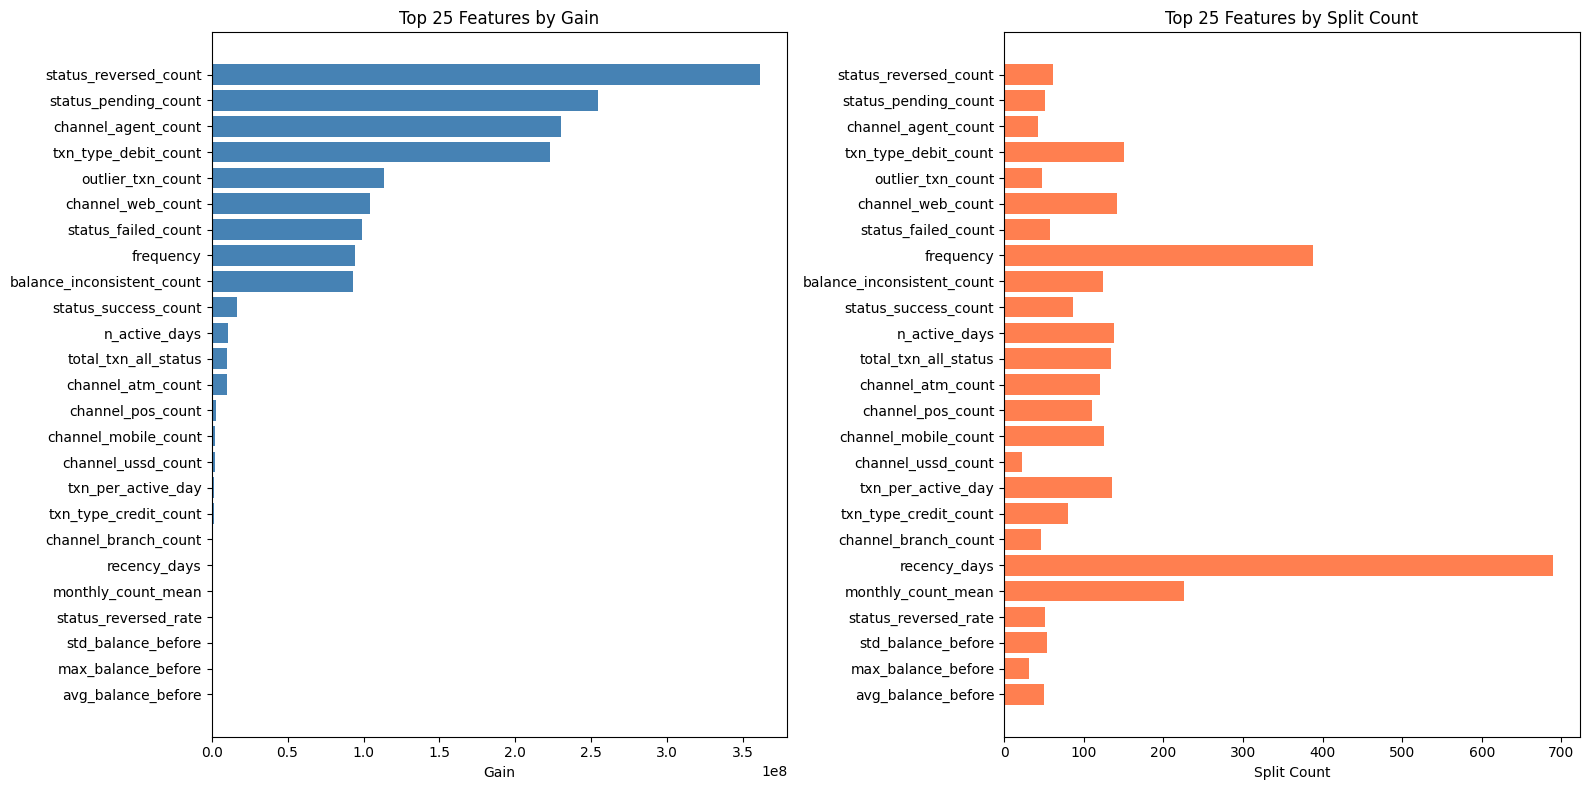


Top 20 by gain:


,feature,importance_gain,importance_split
0,status_reversed_count,3.610721e+08,62
1,status_pending_count,2.541001e+08,52
2,channel_agent_count,2.302255e+08,42
3,txn_type_debit_count,2.229687e+08,150
4,outlier_txn_count,1.137889e+08,48
5,channel_web_count,1.046074e+08,142
6,status_failed_count,9.869085e+07,58
7,frequency,9.408358e+07,388
8,balance_inconsistent_count,9.308216e+07,124
9,status_success_count,1.698588e+07,87


In [17]:
importance = pd.DataFrame({
    "feature":          feature_names,
    "importance_gain":  model.feature_importance(importance_type="gain"),
    "importance_split": model.feature_importance(importance_type="split"),
})
importance = importance.sort_values("importance_gain", ascending=False).reset_index(drop=True)

top_n = 25
top   = importance.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(range(top_n), top["importance_gain"].values,  color="steelblue")
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top["feature"].values)
axes[0].invert_yaxis()
axes[0].set_title(f"Top {top_n} Features by Gain")
axes[0].set_xlabel("Gain")

axes[1].barh(range(top_n), top["importance_split"].values, color="coral")
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top["feature"].values)
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_n} Features by Split Count")
axes[1].set_xlabel("Split Count")

plt.tight_layout()
plt.savefig(f"{OUT}11_feature_importance_lgbm.png", dpi=150)
plt.show()

print("\nTop 20 by gain:")
importance.head(20)[["feature", "importance_gain", "importance_split"]]

### Plot 12: SHAP Feature Importance (Bar)

Mean absolute SHAP values — model-agnostic measure of each feature's average impact on predictions.

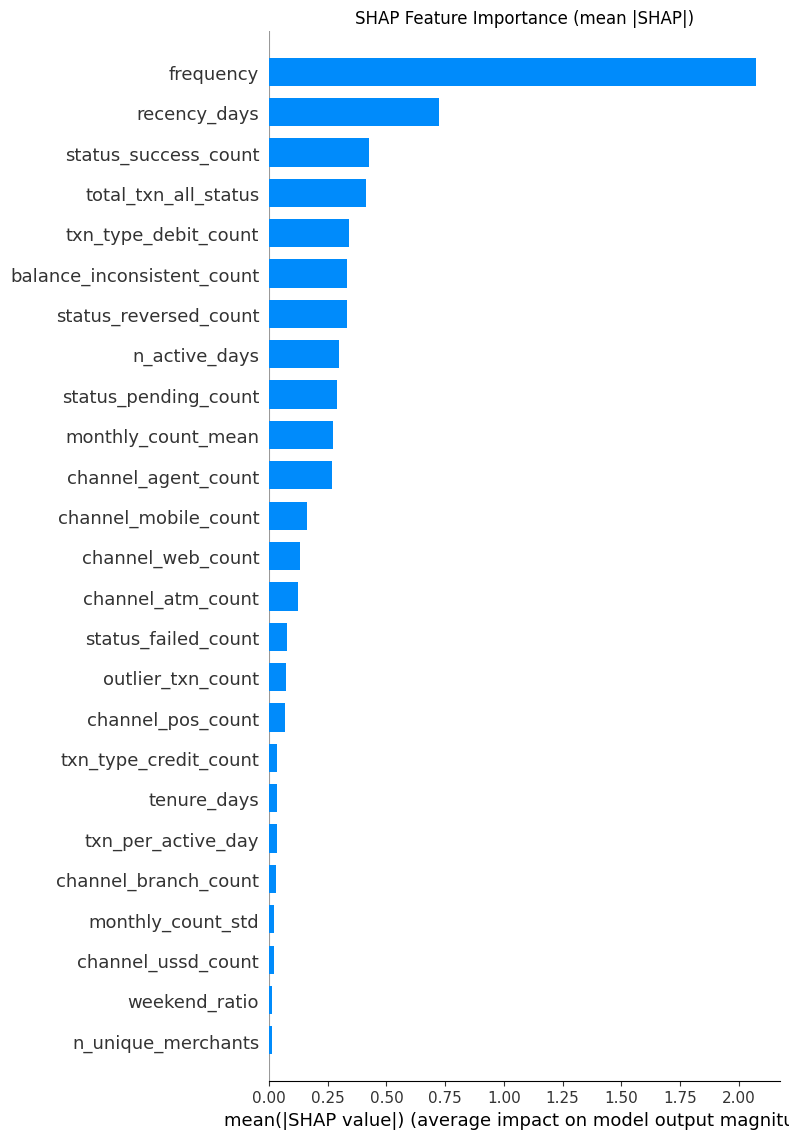

In [18]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=25, show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{OUT}12_shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot 13: SHAP Beeswarm

Shows both the magnitude and direction of each feature's effect on the prediction. Each dot is one customer in the test set; colour indicates feature value (red = high, blue = low).

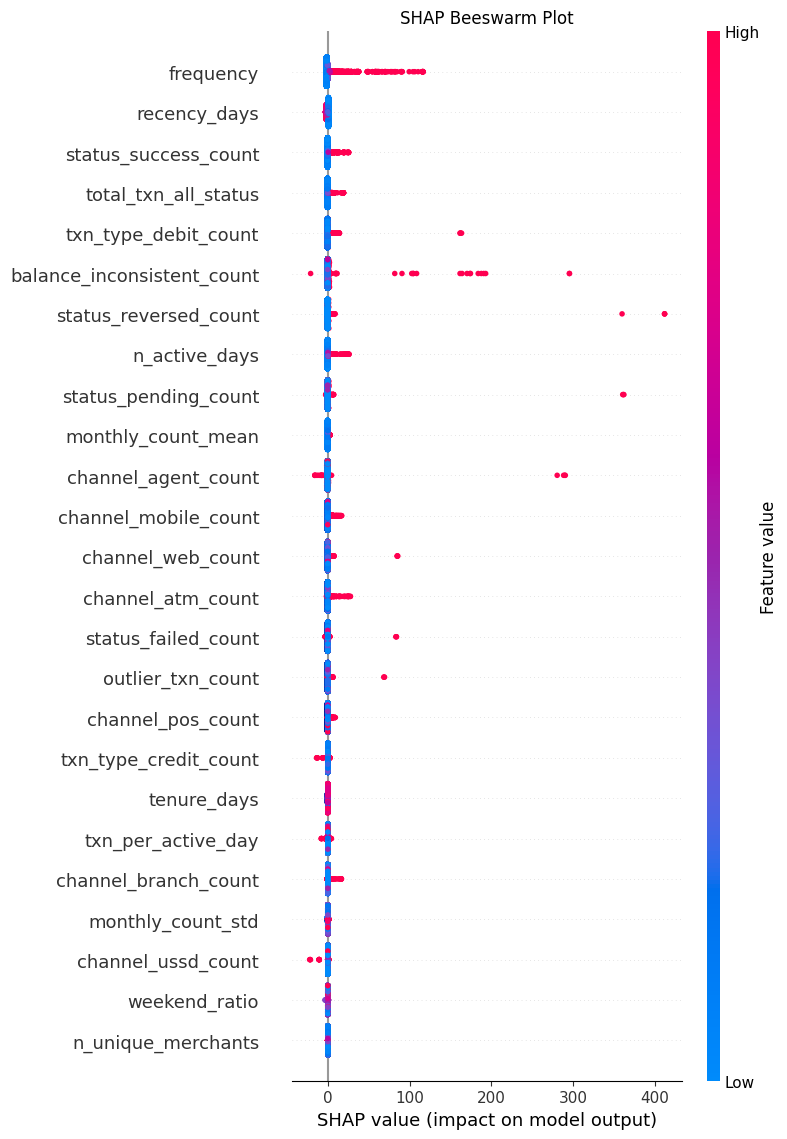

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, max_display=25, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig(f"{OUT}13_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Importance Comparison Table

Side-by-side ranking of LightGBM gain vs mean |SHAP|, sorted by SHAP rank. Saved to `output/feature_importance_table.csv`.

In [20]:
shap_abs_mean = pd.DataFrame({
    "feature":       feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

comparison = importance.merge(shap_abs_mean, on="feature")
comparison["rank_gain"] = comparison["importance_gain"].rank(ascending=False).astype(int)
comparison["rank_shap"] = comparison["mean_abs_shap"].rank(ascending=False).astype(int)
comparison = comparison.sort_values("rank_shap").reset_index(drop=True)

comparison.to_csv(f"{OUT}feature_importance_table.csv", index=False)
print(f"Saved → {OUT}feature_importance_table.csv")

comparison[["feature", "rank_shap", "mean_abs_shap", "rank_gain", "importance_gain"]].head(20)

Saved → output/feature_importance_table.csv


,feature,rank_shap,mean_abs_shap,rank_gain,importance_gain
0,frequency,1,2.072240,8,9.408358e+07
1,recency_days,2,0.725593,20,8.595909e+05
2,status_success_count,3,0.424393,10,1.698588e+07
3,total_txn_all_status,4,0.413454,12,1.025804e+07
4,txn_type_debit_count,5,0.342773,4,2.229687e+08
5,balance_inconsistent_count,6,0.333403,9,9.308216e+07
6,status_reversed_count,7,0.330850,1,3.610721e+08
7,n_active_days,8,0.300181,11,1.103058e+07
8,status_pending_count,9,0.289117,2,2.541001e+08
9,monthly_count_mean,10,0.270821,21,6.325011e+05


### Model Summary

In [21]:
summary = {
    "Model":              "LightGBM Regressor",
    "Target":             f"{target_col} (3-month transaction count)",
    "Features used":      len(feature_names),
    "Train size":         f"{len(X_train):,}",
    "Test size":          f"{len(X_test):,}",
    "Best iteration":     model.best_iteration,
    "Test MAE":           f"{mae:.2f}",
    "Test R²":            f"{r2:.4f}",
    "Top feature (SHAP)": shap_abs_mean.iloc[0]["feature"],
    "Top feature (gain)": importance.iloc[0]["feature"],
}

pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

,Value
Model,LightGBM Regressor
Target,recent_3m_count (3-month transaction count)
Features used,64
Train size,"80,000"
Test size,"20,000"
Best iteration,95
Test MAE,1.32
Test R²,0.7891
Top feature (SHAP),frequency
Top feature (gain),status_reversed_count
